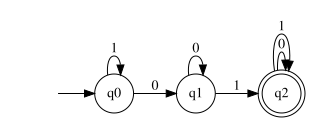

States: {'q1', 'q0', 'q2'}
Alphabet: {'1', '0'}
Start State: q0
Final States: {'q2'}

Transition Table:
q1 -- 1 --> q2
q1 -- 0 --> q1
q0 -- 1 --> q0
q0 -- 0 --> q1
q2 -- 1 --> q2
q2 -- 0 --> q2


In [4]:
import graphviz
from IPython.display import display

states = {'q0', 'q1', 'q2'}
alphabet = {'0', '1'}
start_state = 'q0'
final_states = {'q2'}

transitions = {
    ('q0', '0'): 'q1',
    ('q0', '1'): 'q0',
    ('q1', '0'): 'q1',
    ('q1', '1'): 'q2',
    ('q2', '0'): 'q2',
    ('q2', '1'): 'q2'
}

dot = graphviz.Digraph()
dot.attr(rankdir='LR')

dot.node('', shape='none')

for state in states:
    if state in final_states:
        dot.node(state, shape='doublecircle')
    else:
        dot.node(state, shape='circle')

dot.edge('', start_state)

for (state, symbol), next_state in transitions.items():
    dot.edge(state, next_state, label=symbol)

display(dot)

print("States:", states)
print("Alphabet:", alphabet)
print("Start State:", start_state)
print("Final States:", final_states)

print("\nTransition Table:")

for state in states:
    for symbol in alphabet:
        print(state, "--", symbol, "-->", transitions[(state, symbol)])

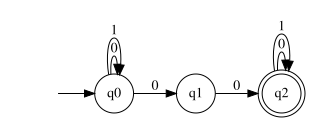

States: {'q1', 'q0', 'q2'}
Alphabet: {'1', '0'}
Start State: q0
Final States: {'q2'}

Transition Table:
q1 -- 1 --> set()
q1 -- 0 --> {'q2'}
q0 -- 1 --> {'q0'}
q0 -- 0 --> {'q1', 'q0'}
q2 -- 1 --> {'q2'}
q2 -- 0 --> {'q2'}


In [5]:
import graphviz
from IPython.display import display

states = {'q0', 'q1', 'q2'}
alphabet = {'0', '1'}
start_state = 'q0'
final_states = {'q2'}

transitions = {
    ('q0', '0'): {'q0', 'q1'},
    ('q0', '1'): {'q0'},
    ('q1', '0'): {'q2'},
    ('q1', '1'): set(),
    ('q2', '0'): {'q2'},
    ('q2', '1'): {'q2'}
}

dot = graphviz.Digraph()
dot.attr(rankdir='LR')

dot.node('', shape='none')

for state in states:
    if state in final_states:
        dot.node(state, shape='doublecircle')
    else:
        dot.node(state, shape='circle')

dot.edge('', start_state)

for (state, symbol), next_states in transitions.items():
    for next_state in next_states:
        dot.edge(state, next_state, label=symbol)

display(dot)

print("States:", states)
print("Alphabet:", alphabet)
print("Start State:", start_state)
print("Final States:", final_states)

print("\nTransition Table:")

for state in states:
    for symbol in alphabet:
        print(state, "--", symbol, "-->", transitions[(state, symbol)])

Original NFA:


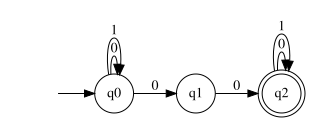

Converted DFA:


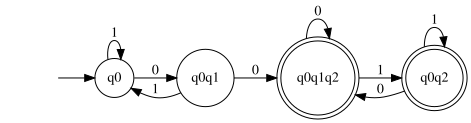


DFA States:
q0
q0q1
q0q1q2
q0q2

DFA Final States:
q0q1q2
q0q2

DFA Transition Table:
q0 -- 1 --> q0
q0 -- 0 --> q0q1
q0q1 -- 1 --> q0
q0q1 -- 0 --> q0q1q2
q0q1q2 -- 1 --> q0q2
q0q1q2 -- 0 --> q0q1q2
q0q2 -- 1 --> q0q2
q0q2 -- 0 --> q0q1q2


In [6]:
import graphviz
from IPython.display import display

nfa_states = {'q0', 'q1', 'q2'}
alphabet = {'0', '1'}
start_state = 'q0'
nfa_final_states = {'q2'}

nfa_transitions = {
    ('q0', '0'): {'q0', 'q1'},
    ('q0', '1'): {'q0'},
    ('q1', '0'): {'q2'},
    ('q1', '1'): set(),
    ('q2', '0'): {'q2'},
    ('q2', '1'): {'q2'}
}

def get_next_state(state_set, symbol):
    result = set()

    for state in state_set:
        result.update(
            nfa_transitions.get((state, symbol), set())
        )

    return frozenset(result)

start_dfa_state = frozenset({start_state})

dfa_states = {start_dfa_state}
dfa_transitions = {}

queue = [start_dfa_state]

while queue:
    current = queue.pop(0)

    for symbol in alphabet:
        next_state = get_next_state(current, symbol)

        dfa_transitions[(current, symbol)] = next_state

        if next_state not in dfa_states:
            dfa_states.add(next_state)
            queue.append(next_state)

dfa_final_states = set()

for state in dfa_states:
    if state & nfa_final_states:
        dfa_final_states.add(state)

def state_name(state):
    if len(state) == 0:
        return '∅'

    return ''.join(sorted(state))

nfa = graphviz.Digraph()
nfa.attr(rankdir='LR')

nfa.node('', shape='none')

for state in nfa_states:
    if state in nfa_final_states:
        nfa.node(state, shape='doublecircle')
    else:
        nfa.node(state, shape='circle')

nfa.edge('', start_state)

for (state, symbol), next_states in nfa_transitions.items():
    for next_state in next_states:
        nfa.edge(state, next_state, label=symbol)

print("Original NFA:")
display(nfa)

dfa = graphviz.Digraph()
dfa.attr(rankdir='LR')

dfa.node('', shape='none')

for state in dfa_states:
    name = state_name(state)

    if state in dfa_final_states:
        dfa.node(name, shape='doublecircle')
    else:
        dfa.node(name, shape='circle')

dfa.edge('', state_name(start_dfa_state))

for (state, symbol), next_state in dfa_transitions.items():
    dfa.edge(
        state_name(state),
        state_name(next_state),
        label=symbol
    )

print("Converted DFA:")
display(dfa)

print("\nDFA States:")

for state in dfa_states:
    print(state_name(state))

print("\nDFA Final States:")

for state in dfa_final_states:
    print(state_name(state))

print("\nDFA Transition Table:")

for (state, symbol), next_state in dfa_transitions.items():
    print(
        state_name(state),
        "--",
        symbol,
        "-->",
        state_name(next_state)
    )